In [3]:
import pandas as pd

ev = pd.read_csv("events.csv")
ev["event_time"] = pd.to_datetime(ev["timestamp"], unit="ms")

print(ev.shape)
print(ev["event"].value_counts())
print(ev["event_time"].min(), "→", ev["event_time"].max())
ev.head()

(2756101, 6)
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64
2015-05-03 03:00:04.384000 → 2015-09-18 02:59:47.788000


,timestamp,visitorid,event,itemid,transactionid,event_time
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106


In [4]:
steps = ["view", "addtocart", "transaction"]

funnel = (
    ev[ev["event"].isin(steps)]
    .groupby("event")["visitorid"].nunique()
    .reindex(steps)
    .to_frame("users")
)

funnel["pct_of_views"] = (funnel["users"] / funnel.loc["view", "users"] * 100).round(2)
funnel["step_drop_off_%"] = (100 - funnel["users"] / funnel["users"].shift(1) * 100).round(2)
funnel

,users,pct_of_views,step_drop_off_%
event,,,
view,1404179,100.00,NaN
addtocart,37722,2.69,97.31
transaction,11719,0.83,68.93


In [5]:
first = (
    ev[ev["event"].isin(steps)]
    .pivot_table(index="visitorid", columns="event", values="event_time", aggfunc="min")
)

s1 = first["view"].notna()
s2 = s1 & (first["addtocart"] >= first["view"])
s3 = s2 & (first["transaction"] >= first["addtocart"])

strict = pd.DataFrame({
    "step": ["view", "addtocart", "transaction"],
    "users": [s1.sum(), s2.sum(), s3.sum()],
})
strict["pct_of_views"] = (strict["users"] / strict.loc[0, "users"] * 100).round(2)
strict["step_drop_off_%"] = (100 - strict["users"] / strict["users"].shift(1) * 100).round(2)
strict

,step,users,pct_of_views,step_drop_off_%
0,view,1404179,100.00,NaN
1,addtocart,32272,2.30,97.7
2,transaction,9682,0.69,70.0


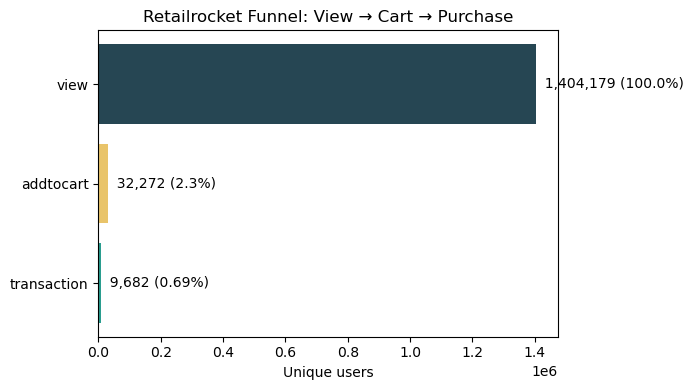

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.barh(strict["step"][::-1], strict["users"][::-1], color=["#2a9d8f", "#e9c46a", "#264653"])
for i, (u, p) in enumerate(zip(strict["users"][::-1], strict["pct_of_views"][::-1])):
    plt.text(u, i, f"  {u:,} ({p}%)", va="center")
plt.title("Retailrocket Funnel: View → Cart → Purchase")
plt.xlabel("Unique users")
plt.tight_layout()
plt.show()

In [7]:
pip install duckdb seaborn

   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
    --------------------------------------- 0.3/13.2 MB ? eta -:--:--
    --------------------------------------- 0.3/13.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.2 MB 574.0 kB/s eta 0:00:23
   - -------------------------------------- 0.5/13.2 MB 574.0 kB/s eta 0:00:23
   - -------------------------------------- 0.5/13.2 MB 574.0 kB/s eta 0:00:23
   -- ------------------------------------- 0.8/13.2 MB 443.2 kB/s eta 0:00:28
   -- ------------------------------------- 0.8/13.2 MB 443.2 kB/s eta 0:00:28
   --- ------------------------------------ 1.0/13.2 MB 498.4 kB/s eta 0:00:25
   --- ------------------------------------ 1.0/13.2 MB 498.4 kB/s eta 0:00:25
   --- --------------------

In [8]:
import duckdb

cohort = duckdb.sql("""
WITH activity AS (
    SELECT DISTINCT visitorid,
           DATE_TRUNC('week', event_time) AS active_week
    FROM ev
    WHERE event_time >= '2015-05-04' AND event_time < '2015-09-14'
),
with_cohort AS (
    SELECT visitorid, active_week,
           MIN(active_week) OVER (PARTITION BY visitorid) AS cohort_week
    FROM activity
)
SELECT cohort_week,
       DATE_DIFF('week', cohort_week, active_week) AS week_number,
       
       COUNT(DISTINCT visitorid) AS users
FROM with_cohort
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

cohort.head(10)

,cohort_week,week_number,users
0,2015-05-04,0,72138
1,2015-05-04,1,3604
2,2015-05-04,2,2104
3,2015-05-04,3,1549
4,2015-05-04,4,1250
5,2015-05-04,5,978
6,2015-05-04,6,962
7,2015-05-04,7,857
8,2015-05-04,8,759
9,2015-05-04,9,755


In [9]:
ret = cohort.pivot(index="cohort_week", columns="week_number", values="users")
ret_pct = ret.div(ret[0], axis=0).mul(100).round(1)
ret_pct.iloc[:, :9]

week_number,0,1,2,3,4,5,6,7,8
cohort_week,,,,,,,,,
2015-05-04,100.0,5.0,2.9,2.1,1.7,1.4,1.3,1.2,1.1
2015-05-11,100.0,4.3,2.1,1.7,1.2,1.1,1.0,0.8,0.9
2015-05-18,100.0,3.5,1.9,1.3,1.1,1.0,0.8,0.8,0.8
2015-05-25,100.0,3.4,1.6,1.2,1.0,0.9,0.9,0.8,0.8
2015-06-01,100.0,3.4,1.8,1.3,1.0,0.9,0.9,0.8,0.7
2015-06-08,100.0,3.4,1.7,1.2,1.1,0.8,0.8,0.6,0.6
2015-06-15,100.0,3.3,1.6,1.4,1.0,0.9,0.7,0.7,0.6
2015-06-22,100.0,3.4,1.7,1.2,1.0,0.8,0.7,0.6,0.6
2015-06-29,100.0,3.4,1.7,1.3,0.9,0.8,0.7,0.6,0.5


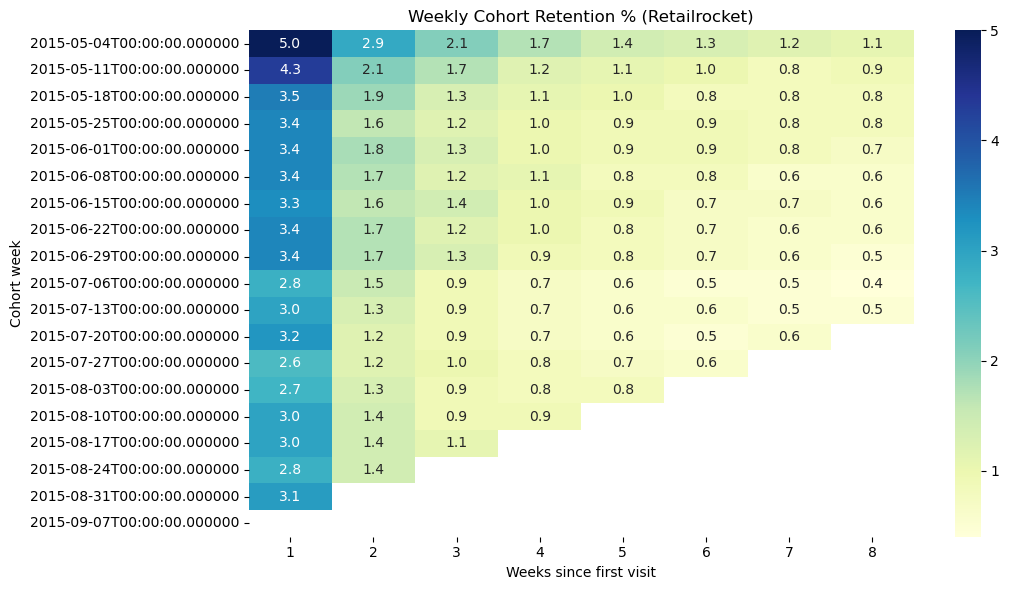

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))
sns.heatmap(ret_pct.iloc[:, 1:9], annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Weekly Cohort Retention % (Retailrocket)")
plt.ylabel("Cohort week")
plt.xlabel("Weeks since first visit")
plt.tight_layout()
plt.show()